In [ ]:
# Upload files to Colab
from google.colab import files
uploaded = files.upload()
print(f"\n✅ Uploaded {len(uploaded)} files:")
for name in uploaded.keys():
    print(f"   - {name}")

Saving december_generator2022_OP.csv to december_generator2022_OP.csv
Saving december_generator2022_PLANNED.csv to december_generator2022_PLANNED.csv
Saving december_generator2023_OP.csv to december_generator2023_OP.csv
Saving december_generator2023_PLANNED.csv to december_generator2023_PLANNED.csv
Saving december_generator2024_OP.csv to december_generator2024_OP.csv
Saving december_generator2024_PLANNED.csv to december_generator2024_PLANNED.csv
Saving december_generator2025_OP.csv to december_generator2025_OP.csv
Saving december_generator2025_PLANNED.csv to december_generator2025_PLANNED.csv

✅ Uploaded 8 files:
   - december_generator2022_OP.csv
   - december_generator2022_PLANNED.csv
   - december_generator2023_OP.csv
   - december_generator2023_PLANNED.csv
   - december_generator2024_OP.csv
   - december_generator2024_PLANNED.csv
   - december_generator2025_OP.csv
   - december_generator2025_PLANNED.csv


In [ ]:
# Import libraries
import pandas as pd
import numpy as np
import warnings
warnings.filterwarnings('ignore')

print("Libraries loaded")

Libraries loaded


Each year has two files:
- **PLANNED**: projects that are proposed/under construction (not yet operating)
- **OP (Operating)**: projects that are already generating electricity

We need to track the same plant from PLANNED → OP to measure how long
construction actually took vs. how long it was supposed to take.

In [ ]:
# Define the years we're working with
YEARS = [2022, 2023, 2024, 2025]

# Load all PLANNED files
planned_dfs = {}
for year in YEARS:
    filename = f'december_generator{year}_PLANNED.csv'
    df = pd.read_csv(filename, encoding='latin-1')
    df.columns = df.columns.str.strip()       # clean whitespace from headers
    df['Technology'] = df['Technology'].astype(str).str.strip()
    planned_dfs[year] = df
    print(f"PLANNED {year}: {len(df)} rows, {df.columns.tolist()}")

PLANNED 2022: 1396 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Planned Operation Month', 'Planned Operation Year', 'Status', 'Latitude', 'Longitude']
PLANNED 2023: 1509 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Planned Operation Month', 'Planned Operation Year', 'Status', 'Latitude', 'Longitude']
PLANNED 2024: 1907 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Planned Operation Month', 'Planned Operation Year', 'Status', 'Latitude', 'Longitude']
PLANNED 2025: 1948 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Planned Operation Month', 'Planned Operation Year', 'Status', 'Latitude', 'Longitude', 'Unnamed: 12']


In [ ]:
# Load all OPERATING files
op_dfs = {}
for year in YEARS:
    filename = f'december_generator{year}_OP.csv'
    df = pd.read_csv(filename, encoding='latin-1')
    df.columns = df.columns.str.strip()
    df['Technology'] = df['Technology'].astype(str).str.strip()
    op_dfs[year] = df
    print(f"OP {year}: {len(df)} rows, {df.columns.tolist()}")

OP 2022: 25111 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Operating Month', 'Operating Year', 'Planned Retirement Month', 'Planned Retirement Year', 'Status', 'Latitude', 'Longitude']
OP 2023: 25889 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Operating Month', 'Operating Year', 'Planned Retirement Month', 'Planned Retirement Year', 'Status', 'Latitude', 'Longitude']
OP 2024: 26797 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Operating Month', 'Operating Year', 'Planned Retirement Month', 'Planned Retirement Year', 'Status', 'Latitude', 'Longitude']
OP 2025: 27687 rows, ['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Op

In [ ]:
# Sample from PLANNED file
print("=" * 60)
print("PLANNED file sample (2022)")
print("=" * 60)
print(planned_dfs[2022].head(5).to_string())
print(f"\nKey columns:")
print(f"  - Entity ID + Plant ID: uniquely identifies a project")
print(f"  - Technology: what kind of generator (solar, wind, gas, etc.)")
print(f"  - Planned Operation Month/Year: when the project EXPECTS to start")
print(f"  - Status: planning stage (V=verified, TS=testing, U=under construction, etc.)")
print(f"  - Latitude/Longitude: project location")

PLANNED file sample (2022)
  Entity ID  Plant ID            Sector Nameplate Capacity (MW) Net Summer Capacity (MW) Net Winter Capacity (MW) Technology  Planned Operation Month  Planned Operation Year Status   Latitude  Longitude
0       803   57561.0  Electric Utility                    17.0                     17.0                     17.0  Batteries                     12.0                  2022.0      V  33.034722  -112.6617
1       803   57562.0  Electric Utility                    17.0                     17.0                     17.0  Batteries                     12.0                  2022.0      V  33.021111  -112.6614
2       803   57563.0  Electric Utility                    16.0                     16.0                     16.0  Batteries                     12.0                  2022.0      V  33.025660  -113.3440
3       803   57997.0  Electric Utility                    38.0                     38.0                     38.0  Batteries                     12.0            

In [ ]:
# Sample from OPERATING file
print("=" * 60)
print("OPERATING file sample (2023)")
print("=" * 60)
print(op_dfs[2023].head(5).to_string())
print(f"\nKey columns:")
print(f"  - Entity ID + Plant ID: same ID system as PLANNED")
print(f"  - Technology: same as PLANNED")
print(f"  - Operating Month/Year: when the project ACTUALLY started operating")
print(f"  - Status: OP = operating")

OPERATING file sample (2023)
  Entity ID  Plant ID            Sector Nameplate Capacity (MW) Net Summer Capacity (MW) Net Winter Capacity (MW)            Technology  Operating Month  Operating Year Planned Retirement Month Planned Retirement Year Status   Latitude  Longitude
0     63560       1.0  Electric Utility                     0.9                      0.4                      0.4     Petroleum Liquids             12.0          2000.0                                                      SB  55.339722  -160.4972
1     63560       1.0  Electric Utility                     0.9                      0.3                      0.3     Petroleum Liquids             12.0          2000.0                                                      OP  55.339722  -160.4972
2     63560       1.0  Electric Utility                     0.5                      0.3                      0.3     Petroleum Liquids             12.0          2010.0                                                      OP  55.3




We only care about **solar** and **wind** projects since those are the ones
that generate ITC and PTC credits.

In [ ]:
# See all technology types in the 2022 PLANNED file
print("Technologies in PLANNED 2022:")
print(planned_dfs[2022]['Technology'].value_counts().to_string())

Technologies in PLANNED 2022:
Technology
Solar Photovoltaic                         785
Batteries                                  256
Onshore Wind Turbine                        97
Conventional Hydroelectric                  85
Natural Gas Fired Combined Cycle            46
Natural Gas Fired Combustion Turbine        35
Natural Gas Internal Combustion Engine      33
Offshore Wind Turbine                       14
Nuclear                                      8
Petroleum Liquids                            7
Other Natural Gas                            7
Other Waste Biomass                          7
All Other                                    4
Natural Gas Steam Turbine                    2
Wood/Wood Waste Biomass                      2
Landfill Gas                                 2
nan                                          2
Natural Gas with Compressed Air Storage      2
Geothermal                                   1
Solar Thermal without Energy Storage         1


In [ ]:
# Technologies we want to keep
SOLAR_WIND = [
    'Solar Photovoltaic',
    'Onshore Wind Turbine',
    'Offshore Wind Turbine',
    'Solar Thermal without Energy Storage',
    'Solar Thermal with Energy Storage'
]

# Quick count of solar/wind across all years
print(f"{'Year':<8} {'PLANNED solar/wind':<22} {'OP solar/wind (all)':<22} {'OP solar/wind (2023-25)'}")
print("-" * 75)
for year in YEARS:
    pl_count = len(planned_dfs[year][planned_dfs[year]['Technology'].isin(SOLAR_WIND)])
    op_count = len(op_dfs[year][op_dfs[year]['Technology'].isin(SOLAR_WIND)])
    op_recent = op_dfs[year][
        (op_dfs[year]['Technology'].isin(SOLAR_WIND)) &
        (op_dfs[year]['Operating Year'].between(2023, 2025))
    ]
    print(f"{year:<8} {pl_count:<22} {op_count:<22} {len(op_recent)}")

Year     PLANNED solar/wind     OP solar/wind (all)    OP solar/wind (2023-25)
---------------------------------------------------------------------------
2022     897                    7124                   0
2023     911                    7752                   436
2024     1117                   8526                   1192
2025     1059                   9361                   1984


1.3 Filter to solar & wind only

In [ ]:
# Filter PLANNED files to solar/wind
planned_filtered = {}
for year in YEARS:
    df = planned_dfs[year][planned_dfs[year]['Technology'].isin(SOLAR_WIND)].copy()
    df['source_year'] = year   # remember which file this came from
    planned_filtered[year] = df
    print(f"PLANNED {year} after filter: {len(df)} solar/wind projects")

PLANNED 2022 after filter: 897 solar/wind projects
PLANNED 2023 after filter: 911 solar/wind projects
PLANNED 2024 after filter: 1117 solar/wind projects
PLANNED 2025 after filter: 1059 solar/wind projects


In [ ]:
# Filter OPERATING files to solar/wind, operating year 2023-2025 only
op_filtered = {}
for year in YEARS:
    df = op_dfs[year][
        (op_dfs[year]['Technology'].isin(SOLAR_WIND)) &
        (op_dfs[year]['Operating Year'].between(2023, 2025))
    ].copy()
    df['source_year'] = year
    op_filtered[year] = df
    print(f"OP {year} after filter: {len(df)} solar/wind projects (operating 2023-2025)")

OP 2022 after filter: 0 solar/wind projects (operating 2023-2025)
OP 2023 after filter: 436 solar/wind projects (operating 2023-2025)
OP 2024 after filter: 1192 solar/wind projects (operating 2023-2025)
OP 2025 after filter: 1984 solar/wind projects (operating 2023-2025)


1.4 Create unique plant identifier

use **Entity ID + Plant ID** to identify each plant

In [ ]:
# Check uniqueness in PLANNED 2022
pl_2022 = planned_filtered[2022]
print(f"Total rows: {len(pl_2022)}")
print(f"Unique Plant IDs alone: {pl_2022['Plant ID'].nunique()}")
print(f"Unique Entity ID + Plant ID combos: {pl_2022.groupby(['Entity ID','Plant ID']).ngroups}")
print()
print("→ Entity ID + Plant ID gives us a unique key for each project.")

Total rows: 897
Unique Plant IDs alone: 869
Unique Entity ID + Plant ID combos: 869

→ Entity ID + Plant ID gives us a unique key for each project.


In [ ]:
# Create the unique key for all filtered data
for year in YEARS:
    planned_filtered[year]['plant_key'] = (
        planned_filtered[year]['Entity ID'].astype(str) + '_' +
        planned_filtered[year]['Plant ID'].astype(int).astype(str)
    )

for year in YEARS:
    op_filtered[year]['plant_key'] = (
        op_filtered[year]['Entity ID'].astype(str) + '_' +
        op_filtered[year]['Plant ID'].astype(int).astype(str)
    )

print("✅ plant_key created for all datasets")

✅ plant_key created for all datasets


In [ ]:
# Show a few planned solar projects from 2022
print("Sample planned solar projects (2022):")
cols = ['plant_key', 'Technology', 'Planned Operation Month', 'Planned Operation Year',
        'Status', 'Nameplate Capacity (MW)', 'Latitude', 'Longitude']
print(planned_filtered[2022][cols].head(10).to_string(index=False))

Sample planned solar projects (2022):
  plant_key           Technology  Planned Operation Month  Planned Operation Year Status Nameplate Capacity (MW)  Latitude  Longitude
61298_59997   Solar Photovoltaic                     12.0                  2022.0      U                    16.0 35.396478  -81.21914
61298_60002   Solar Photovoltaic                     12.0                  2022.0      L                    20.0 35.964202  -78.09807
61768_62248   Solar Photovoltaic                     12.0                  2022.0     TS                   200.0 36.459259 -114.84440
59474_62737   Solar Photovoltaic                     12.0                  2022.0     TS                     5.0 42.442927  -78.63214
59474_62738   Solar Photovoltaic                     12.0                  2022.0     TS                     5.0 42.443632  -78.63213
64084_64507   Solar Photovoltaic                     12.0                  2022.0      U                   100.0 36.386380  -88.99194
64362_64841   Solar Phot

In [ ]:
# Show a few operating solar projects from 2023
print("\nSample operating solar projects (2023):")
cols_op = ['plant_key', 'Technology', 'Operating Month', 'Operating Year',
           'Status', 'Nameplate Capacity (MW)', 'Latitude', 'Longitude']
print(op_filtered[2023][cols_op].head(10).to_string(index=False))


Sample operating solar projects (2023):
  plant_key           Technology  Operating Month  Operating Year Status Nameplate Capacity (MW)  Latitude  Longitude
 40230_7790   Solar Photovoltaic              5.0          2023.0     OP                    12.5 40.086400 -109.28440
61950_10444   Solar Photovoltaic              7.0          2023.0     OP                   100.4 35.030800 -117.35630
64994_60020   Solar Photovoltaic              8.0          2023.0     OP                     4.9 34.781934  -79.49775
64994_60028   Solar Photovoltaic              8.0          2023.0     OP                     8.9 34.680287  -79.54074
56215_60596 Onshore Wind Turbine              2.0          2023.0     OP                   130.0 42.375000  -77.59300
64281_60850   Solar Photovoltaic             12.0          2023.0     OP                     5.0 34.709198  -79.35190
61069_61446   Solar Photovoltaic              5.0          2023.0     OP                    45.0 34.834944 -118.55120
61069_61447   S

In [ ]:
# ITC and PTC quarterly prices
price_data = pd.DataFrame({
    'period':  ['2023H2','2024Q1','2024Q2','2024Q3','2024Q4',
                '2025Q1','2025Q2','2025Q3','2025Q4'],
    'ITC':     [91.5, 92.4, 92.3, 92.8, 93.5, 93.0, 91.5, 89.3, 89.0],
    'PTC':     [94.0, 95.2, 95.0, 95.3, 95.5, 93.1, 92.5, 91.6, 91.0]
})

print("ITC/PTC Quarterly Prices (cents per dollar of credit):")
print(price_data.to_string(index=False))

ITC/PTC Quarterly Prices (cents per dollar of credit):
period  ITC  PTC
2023H2 91.5 94.0
2024Q1 92.4 95.2
2024Q2 92.3 95.0
2024Q3 92.8 95.3
2024Q4 93.5 95.5
2025Q1 93.0 93.1
2025Q2 91.5 92.5
2025Q3 89.3 91.6
2025Q4 89.0 91.0


In [ ]:
# Concatenate all planned and operating data into single DataFrames for easier matching
all_planned = pd.concat(planned_filtered.values(), ignore_index=True)
all_op = pd.concat(op_filtered.values(), ignore_index=True)

print(f"Total unique planned projects: {all_planned['plant_key'].nunique()}")
print(f"Total unique operating projects: {all_op['plant_key'].nunique()}")

Total unique planned projects: 2264
Total unique operating projects: 3111


In [ ]:
# Merge planned and operating dataframes on 'plant_key' and 'Technology'
# We use a left merge from 'all_planned' to keep all planned projects, and then
# filter for those that have a match in 'all_op'.

# Rename columns from operating data to avoid conflicts
op_renamed = all_op.rename(columns={
    'Operating Month': 'Actual Operating Month',
    'Operating Year': 'Actual Operating Year',
    'Status': 'Actual Status'
})

# Select relevant columns from operating data for merging
op_cols = ['plant_key', 'Technology', 'Actual Operating Month', 'Actual Operating Year', 'Actual Status']

merged_df = pd.merge(
    all_planned,
    op_renamed[op_cols],
    on=['plant_key', 'Technology'],
    how='left'
)

# Filter for projects that actually became operational (i.e., have 'Actual Operating Year')
completed_projects = merged_df[merged_df['Actual Operating Year'].notna()].copy()

print(f"Number of planned projects that became operational: {len(completed_projects)}")
print("Columns after merge:")
print(completed_projects.columns.tolist())

display(completed_projects.head())

Number of planned projects that became operational: 1044
Columns after merge:
['Entity ID', 'Plant ID', 'Sector', 'Nameplate Capacity (MW)', 'Net Summer Capacity (MW)', 'Net Winter Capacity (MW)', 'Technology', 'Planned Operation Month', 'Planned Operation Year', 'Status', 'Latitude', 'Longitude', 'source_year', 'plant_key', 'Unnamed: 12', 'Actual Operating Month', 'Actual Operating Year', 'Actual Status']


,Entity ID,Plant ID,Sector,Nameplate Capacity (MW),Net Summer Capacity (MW),Net Winter Capacity (MW),Technology,Planned Operation Month,Planned Operation Year,Status,Latitude,Longitude,source_year,plant_key,Unnamed: 12,Actual Operating Month,Actual Operating Year,Actual Status
2,61768,62248.0,IPP Non-CHP,200.0,200.0,200.0,Solar Photovoltaic,12.0,2022.0,TS,36.459259,-114.8444,2022,61768_62248,NaN,12.0,2023.0,OP
3,61768,62248.0,IPP Non-CHP,200.0,200.0,200.0,Solar Photovoltaic,12.0,2022.0,TS,36.459259,-114.8444,2022,61768_62248,NaN,12.0,2023.0,OP
6,64084,64507.0,IPP Non-CHP,100.0,100.0,100.0,Solar Photovoltaic,12.0,2022.0,U,36.38638,-88.99194,2022,64084_64507,NaN,3.0,2023.0,OP
7,64084,64507.0,IPP Non-CHP,100.0,100.0,100.0,Solar Photovoltaic,12.0,2022.0,U,36.38638,-88.99194,2022,64084_64507,NaN,3.0,2023.0,OP
9,64505,65107.0,IPP Non-CHP,70.2,70.2,70.2,Solar Photovoltaic,12.0,2022.0,V,35.33604,-79.7417,2022,64505_65107,NaN,1.0,2023.0,OP


In [ ]:
# Convert month/year columns to datetime objects for easy calculation
completed_projects['Planned Operation Date'] = pd.to_datetime(
    completed_projects['Planned Operation Year'].astype(int).astype(str) + '-' +
    completed_projects['Planned Operation Month'].astype(int).astype(str) + '-01'
)
completed_projects['Actual Operating Date'] = pd.to_datetime(
    completed_projects['Actual Operating Year'].astype(int).astype(str) + '-' +
    completed_projects['Actual Operating Month'].astype(int).astype(str) + '-01'
)

# Calculate delay in months
completed_projects['delay_months'] = (
    (completed_projects['Actual Operating Date'].dt.year - completed_projects['Planned Operation Date'].dt.year) * 12 +
    (completed_projects['Actual Operating Date'].dt.month - completed_projects['Planned Operation Date'].dt.month)
)

# Handle projects that were completed early (negative delay)
# For the purpose of 'delay', we are interested in actual delays, so early completion can be set to 0 or ignored depending on analysis goals.
# For now, let's keep negative values to see the full spectrum.

print("Projects with calculated delays:")
display(completed_projects[['plant_key', 'Technology', 'Planned Operation Date', 'Actual Operating Date', 'delay_months']].head())

Projects with calculated delays:


,plant_key,Technology,Planned Operation Date,Actual Operating Date,delay_months
2,61768_62248,Solar Photovoltaic,2022-12-01,2023-12-01,12
3,61768_62248,Solar Photovoltaic,2022-12-01,2023-12-01,12
6,64084_64507,Solar Photovoltaic,2022-12-01,2023-03-01,3
7,64084_64507,Solar Photovoltaic,2022-12-01,2023-03-01,3
9,64505_65107,Solar Photovoltaic,2022-12-01,2023-01-01,1


In [ ]:
# Extract year and quarter from Actual Operating Date
completed_projects['Actual Operating Year Quarter'] = completed_projects['Actual Operating Date'].dt.to_period('Q')

# Group by quarter and calculate relevant statistics
quarterly_delays = completed_projects.groupby('Actual Operating Year Quarter').agg(
    total_capacity_mw=('Nameplate Capacity (MW)', 'sum'),
    average_delay_months=('delay_months', 'mean'),
    num_projects=('plant_key', 'nunique')
).reset_index()

# Convert 'Actual Operating Year Quarter' to a string format that matches 'price_data' period (e.g., '2023Q1')
# Note: '2023Q2' for price_data covers H2 (Q3+Q4), so we need to be careful with matching.
# For simplicity, let's assume '2023Q2' in price_data can be approximated for Q3/Q4, or align later.
# For now, let's format for Q1-Q4.
quarterly_delays['period'] = quarterly_delays['Actual Operating Year Quarter'].astype(str)

print("Quarterly aggregated delays:")
display(quarterly_delays.head())

Quarterly aggregated delays:


,Actual Operating Year Quarter,total_capacity_mw,average_delay_months,num_projects,period
0,2023Q1,100.0100.070.270.21.01.01.01.0101.2101.2130.01...,0.163399,78,2023Q1
1,2023Q2,200.5200.5350.2300.0300.0172.8172.88.08.03.83....,1.797619,43,2023Q2
2,2023Q3,210.09.89.8500.06.45.05.02.62.670.070.01.01.02...,1.125926,61,2023Q3
3,2023Q4,200.0200.060.060.03.03.05.05.05.05.0111.8111.8...,3.925743,90,2023Q4
4,2024Q1,35.065.02.0100.0100.02.04.33.31.45.020.020.01....,1.377358,92,2024Q1


In [ ]:
# To merge correctly, we need to ensure the 'period' columns match.
# The 'quarterly_delays' DataFrame has periods like '2023Q1', '2023Q2', etc.
# The 'price_data' DataFrame has '2023H2' (which combines Q3 and Q4), then '2024Q1', '2024Q2', etc.

# Create a function to map '2023Q3' and '2023Q4' to '2023H2'
def map_quarter_to_price_period(quarter_str):
    if quarter_str in ['2023Q3', '2023Q4']:
        return '2023H2'
    else:
        return quarter_str

quarterly_delays['price_period'] = quarterly_delays['period'].apply(map_quarter_to_price_period)

# Merge the dataframes
merged_analysis_df = pd.merge(
    quarterly_delays,
    price_data,
    left_on='price_period',
    right_on='period',
    how='left'
)

# Drop the redundant 'period_y' column and rename 'period_x' if necessary
merged_analysis_df = merged_analysis_df.drop(columns=['period_y']).rename(columns={'period_x': 'quarter'})

print("Merged quarterly delays with ITC/PTC prices:")
display(merged_analysis_df.head())

Merged quarterly delays with ITC/PTC prices:


,Actual Operating Year Quarter,total_capacity_mw,average_delay_months,num_projects,quarter,price_period,ITC,PTC
0,2023Q1,100.0100.070.270.21.01.01.01.0101.2101.2130.01...,0.163399,78,2023Q1,2023Q1,NaN,NaN
1,2023Q2,200.5200.5350.2300.0300.0172.8172.88.08.03.83....,1.797619,43,2023Q2,2023Q2,NaN,NaN
2,2023Q3,210.09.89.8500.06.45.05.02.62.670.070.01.01.02...,1.125926,61,2023Q3,2023H2,91.5,94.0
3,2023Q4,200.0200.060.060.03.03.05.05.05.05.0111.8111.8...,3.925743,90,2023Q4,2023H2,91.5,94.0
4,2024Q1,35.065.02.0100.0100.02.04.33.31.45.020.020.01....,1.377358,92,2024Q1,2024Q1,92.4,95.2


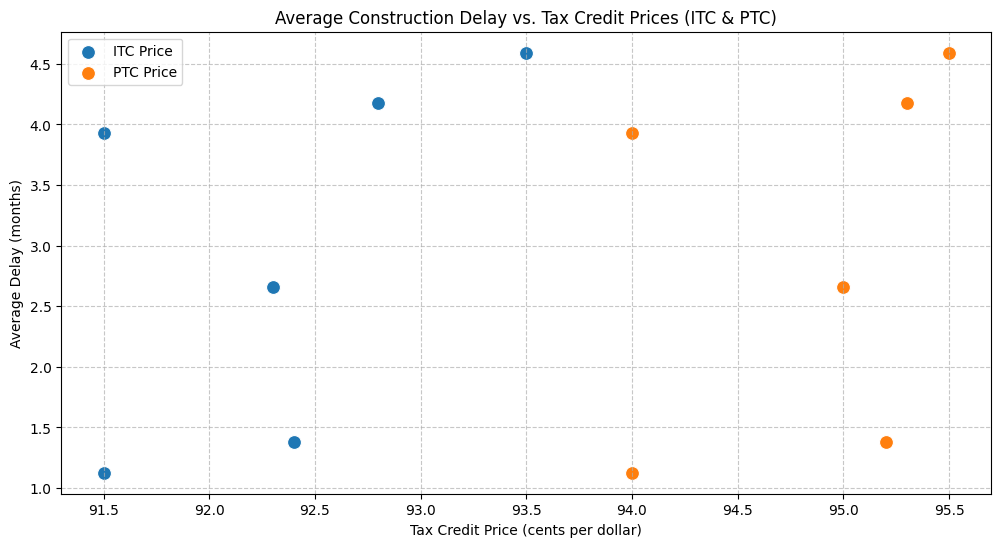

In [ ]:
# Visualize the relationship between average delay and ITC/PTC prices
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(12, 6))

# Scatter plot for ITC prices vs. average delay
sns.scatterplot(
    x='ITC',
    y='average_delay_months',
    data=merged_analysis_df.dropna(subset=['ITC', 'PTC']),
    label='ITC Price',
    s=100  # Size of points
)

# Scatter plot for PTC prices vs. average delay
sns.scatterplot(
    x='PTC',
    y='average_delay_months',
    data=merged_analysis_df.dropna(subset=['ITC', 'PTC']),
    label='PTC Price',
    s=100  # Size of points
)

plt.title('Average Construction Delay vs. Tax Credit Prices (ITC & PTC)')
plt.xlabel('Tax Credit Price (cents per dollar)')
plt.ylabel('Average Delay (months)')
plt.grid(True, linestyle='--', alpha=0.7)
plt.legend()
plt.show()

In [ ]:
import statsmodels.formula.api as smf

# Drop rows with NaN values in ITC or PTC for regression analysis
reg_df = merged_analysis_df.dropna(subset=['ITC', 'PTC']).copy()

print("Regression Analysis: Average Delay vs. ITC Price")
itc_model = smf.ols('average_delay_months ~ ITC', data=reg_df).fit()
print(itc_model.summary())

print("\nRegression Analysis: Average Delay vs. PTC Price")
ptc_model = smf.ols('average_delay_months ~ PTC', data=reg_df).fit()
print(ptc_model.summary())

Regression Analysis: Average Delay vs. ITC Price
                             OLS Regression Results                             
Dep. Variable:     average_delay_months   R-squared:                       0.293
Model:                              OLS   Adj. R-squared:                  0.116
Method:                   Least Squares   F-statistic:                     1.657
Date:                  Mon, 27 Apr 2026   Prob (F-statistic):              0.267
Time:                          19:32:16   Log-Likelihood:                -9.3001
No. Observations:                     6   AIC:                             22.60
Df Residuals:                         4   BIC:                             22.18
Df Model:                             1                                         
Covariance Type:              nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
--------------------------------------------------------------

/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "
/usr/local/lib/python3.12/dist-packages/statsmodels/stats/stattools.py:74: ValueWarning: omni_normtest is not valid with less than 8 observations; 6 samples were given.
  warn("omni_normtest is not valid with less than 8 observations; %i "


In [ ]:
# Import necessary libraries for machine learning
from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_absolute_error, mean_squared_error
import numpy as np

print("Machine learning libraries imported.")

Machine learning libraries imported.


In [ ]:
# Select features (X) and target (y)
# We'll use relevant columns from our completed_projects dataframe
# For simplicity, let's select a few numerical and categorical features.

# Drop rows where 'delay_months' is NaN, as these cannot be used for training
ml_df = completed_projects.dropna(subset=['delay_months']).copy()

# Filter out rows where 'Planned Operation Month' or 'Planned Operation Year' are NaN
ml_df = ml_df.dropna(subset=['Planned Operation Month', 'Planned Operation Year', 'Nameplate Capacity (MW)', 'Technology', 'Status', 'Latitude', 'Longitude'])

features = [
    'Nameplate Capacity (MW)',
    'Planned Operation Month',
    'Planned Operation Year',
    'Technology',
    'Status',
    'Latitude',
    'Longitude'
]
target = 'delay_months'

X = ml_df[features]
y = ml_df[target]

print(f"Selected features: {features}")
print(f"Target variable: {target}")
print(f"Shape of X: {X.shape}")
print(f"Shape of y: {y.shape}")

Selected features: ['Nameplate Capacity (MW)', 'Planned Operation Month', 'Planned Operation Year', 'Technology', 'Status', 'Latitude', 'Longitude']
Target variable: delay_months
Shape of X: (1044, 7)
Shape of y: (1044,)


In [ ]:
# Handle categorical features using one-hot encoding
X_encoded = pd.get_dummies(X, columns=['Technology', 'Status'], drop_first=True)

print("Categorical features one-hot encoded.")
print(f"Shape of encoded X: {X_encoded.shape}")
display(X_encoded.head())

Categorical features one-hot encoded.
Shape of encoded X: (1044, 11)


,Nameplate Capacity (MW),Planned Operation Month,Planned Operation Year,Latitude,Longitude,Technology_Solar Photovoltaic,Status_P,Status_T,Status_TS,Status_U,Status_V
2,200.0,12.0,2022.0,36.459259,-114.8444,True,False,False,True,False,False
3,200.0,12.0,2022.0,36.459259,-114.8444,True,False,False,True,False,False
6,100.0,12.0,2022.0,36.38638,-88.99194,True,False,False,False,True,False
7,100.0,12.0,2022.0,36.38638,-88.99194,True,False,False,False,True,False
9,70.2,12.0,2022.0,35.33604,-79.7417,True,False,False,False,False,True


In [ ]:
# Split the data into training and testing sets
X_train, X_test, y_train, y_test = train_test_split(X_encoded, y, test_size=0.2, random_state=42)

print(f"Training set size: {len(X_train)} samples")
print(f"Testing set size: {len(X_test)} samples")

Training set size: 835 samples
Testing set size: 209 samples


In [ ]:
# Initialize and train a RandomForestRegressor model
# RandomForests are robust to outliers and can capture complex relationships.
model = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1) # n_jobs=-1 uses all available cores
model.fit(X_train, y_train)

print("Random Forest Regressor model trained.")

Random Forest Regressor model trained.


Mean Absolute Error (MAE): 1.71 months
Root Mean Squared Error (RMSE): 2.93 months
R-squared: 0.63


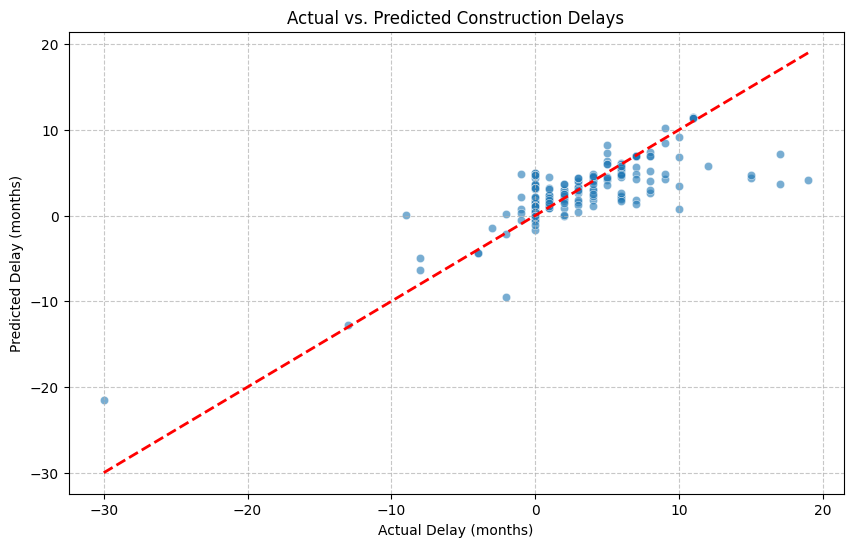

In [ ]:
# Make predictions on the test set
y_pred = model.predict(X_test)

# Evaluate the model
mae = mean_absolute_error(y_test, y_pred)
rmse = np.sqrt(mean_squared_error(y_test, y_pred))
r_squared = model.score(X_test, y_test)

print(f"Mean Absolute Error (MAE): {mae:.2f} months")
print(f"Root Mean Squared Error (RMSE): {rmse:.2f} months")
print(f"R-squared: {r_squared:.2f}")

# Optionally, visualize predictions vs actuals
plt.figure(figsize=(10, 6))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.6)
plt.plot([y_test.min(), y_test.max()], [y_test.min(), y_test.max()], 'r--', lw=2) # y=x line
plt.xlabel('Actual Delay (months)')
plt.ylabel('Predicted Delay (months)')
plt.title('Actual vs. Predicted Construction Delays')
plt.grid(True, linestyle='--', alpha=0.7)
plt.show()

In [ ]:
# Store results for each technology
tech_prediction_results = {}

# Get unique technology types
unique_technologies = ml_df['Technology'].unique()

print(f"Starting delay prediction for {len(unique_technologies)} unique technology types.")

for tech in unique_technologies:
    print(f"\n--- Analyzing Technology: {tech} ---")

    # Filter data for the current technology
    tech_df = ml_df[ml_df['Technology'] == tech].copy()

    if len(tech_df) < 2: # Need at least 2 samples for train/test split
        print(f"Skipping {tech} due to insufficient data ({len(tech_df)} samples).")
        continue

    X_tech = tech_df[features]
    y_tech = tech_df[target]

    # Handle categorical features for the current technology
    # It's important to only encode 'Status' here, as 'Technology' is already filtered
    X_tech_encoded = pd.get_dummies(X_tech, columns=['Technology', 'Status'], drop_first=True)

    # Drop 'Technology' columns if they are all False/zero after filtering for a single technology
    # This handles cases where drop_first might keep a column if there are only two unique categories (one becomes true, one becomes false)
    # but here we've filtered to only one so there will be no `True` in any Technology_ column.
    for col in X_tech_encoded.columns:
        if 'Technology_' in str(col) and X_tech_encoded[col].sum() == 0: # Check if all values are 0 (False)
            X_tech_encoded = X_tech_encoded.drop(columns=[col])


    if len(X_tech_encoded) < 2: # Check again after encoding
        print(f"Skipping {tech} due to insufficient data after encoding ({len(X_tech_encoded)} samples).")
        continue

    # Split data for the current technology
    try:
        X_train_tech, X_test_tech, y_train_tech, y_test_tech = train_test_split(
            X_tech_encoded,
            y_tech,
            test_size=0.2,
            random_state=42,
            shuffle=True # Ensure shuffling even with small datasets
        )
    except ValueError as e:
        print(f"Could not split data for {tech}: {e}. Skipping.")
        continue

    if len(X_train_tech) == 0 or len(X_test_tech) == 0:
        print(f"Skipping {tech} due to empty train or test set after split.")
        continue

    # Train a new RandomForestRegressor for this technology
    model_tech = RandomForestRegressor(n_estimators=100, random_state=42, n_jobs=-1)
    model_tech.fit(X_train_tech, y_train_tech)

    # Make predictions and evaluate
    y_pred_tech = model_tech.predict(X_test_tech)

    mae_tech = mean_absolute_error(y_test_tech, y_pred_tech)
    rmse_tech = np.sqrt(mean_squared_error(y_test_tech, y_pred_tech))
    r_squared_tech = model_tech.score(X_test_tech, y_test_tech)

    tech_prediction_results[tech] = {
        'MAE': mae_tech,
        'RMSE': rmse_tech,
        'R-squared': r_squared_tech,
        'Num Samples': len(tech_df)
    }

    print(f"  MAE: {mae_tech:.2f} months")
    print(f"  RMSE: {rmse_tech:.2f} months")
    print(f"  R-squared: {r_squared_tech:.2f}")
    print(f"  Number of projects: {len(tech_df)}")

print("\n--- Summary of Prediction Results by Technology ---")
for tech, metrics in tech_prediction_results.items():
    print(f"Technology: {tech} (Samples: {metrics['Num Samples']})")
    print(f"  MAE: {metrics['MAE']:.2f}")
    print(f"  RMSE: {metrics['RMSE']:.2f}")
    print(f"  R-squared: {metrics['R-squared']:.2f}")

Starting delay prediction for 2 unique technology types.

--- Analyzing Technology: Solar Photovoltaic ---
  MAE: 1.91 months
  RMSE: 3.08 months
  R-squared: 0.70
  Number of projects: 970

--- Analyzing Technology: Onshore Wind Turbine ---
  MAE: 6.13 months
  RMSE: 15.29 months
  R-squared: 0.22
  Number of projects: 74

--- Summary of Prediction Results by Technology ---
Technology: Solar Photovoltaic (Samples: 970)
  MAE: 1.91
  RMSE: 3.08
  R-squared: 0.70
Technology: Onshore Wind Turbine (Samples: 74)
  MAE: 6.13
  RMSE: 15.29
  R-squared: 0.22
